---
format: 
    html:
        page-layout: full
        embed-resources: True
        grid:
            body-width: 1200px
        fontsize: 18px
        code-fold: true
        code-summary: "Show the code"
        code-tools: true
        code-copy: false
        number-sections: true

title: Dual Momentum Equities Module - Case Study
author: Rui Carvalho Caseiro
date: last-modified

warning: False
toc: True
---

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np
import yfinance as yf
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import warnings
warnings.filterwarnings("ignore")

import MyCustomLibrary.main as main
import MyCustomLibrary.backtester as bt
import MyCustomLibrary.backtester_tools as tools
import MyCustomLibrary.features as my_ta

## Study overview

The intent of this study is to analyze out-of-sample performance of Dual Momentum Tactical Asset Allocation model since it's been published back in 2012. 

Dual Momentum TAA as per the author:

> In our momentum match ups, we use a two-stage selection process. First, we choose between our module's non-Treasury bill assets using relative strength momentum. If our selected 
asset does not also show positive momentum with respect to Treasury bills (meaning it does not have positive absolute momentum), we select Treasury bills as an alternative proxy investment until our selected asset is stronger than Treasury bills.
> [Antonnaci (2016)](https://papers.ssrn.com/sol3/Papers.cfm?abstract_id=2042750)


Antonnaci (2016) has analyzed 4 differente modules in its study:

 - Equity/Sovereign Risk            (US Equity & All-World ex-US)
 - Credit Risk                      (High Yield & Credit Bond)
 - Real Estate Risk                 (Equity REIT & Mortgage REIT)
 - Economic Stress                  (Gold & Treasury Bond)

In each of the studied modules, for the sample period (1974-2011) a Dual Momentum approach improved both annualized returns and Sharpe ratios while at the same time reduced drawdowns.

**This particular study aims to evaluate the out-of-sample performance of the equities module from january 2012 to january 2026.** Using SPDR S&P 500 ETF (SPY) as the US Equity index, Vanguard FTSE All-World ex-US ETF (VEU) as the World-US equity index and SPDR 1–3 Month Treasury Bill ETF (BIL) as the T Bills ETF.

## Data

In [2]:
# SPY – SPDR S&P 500 ETF
# VEU – Vanguard FTSE All-World ex-US ETF
# BIL – SPDR 1–3 Month Treasury Bill ETF

tickers = ['SPY', 'VEU', 'BIL']

quotes = yf.download(tickers, interval='1mo',
                     start='2010-12-31', end='2026-01-02',
                     progress=False, auto_adjust=True)
quotes = quotes.swaplevel(axis='columns').sort_index(axis='columns')
quotes.dropna(inplace=True)

quotes

Ticker       BIL                                 SPY                       \
Price      Close  High   Low  Open     Volume  Close   High    Low   Open   
Date                                                                        
2011-01-01 74.54 74.55 74.54 74.54    3208800  98.44  99.72  96.16  96.93   
2011-02-01 74.54 74.55 74.54 74.54    3552550 101.86 103.04  98.98  99.04   
2011-03-01 74.54 74.57 74.54 74.55    8731800 101.43 102.27  95.84 102.18   
2011-04-01 74.54 74.57 74.54 74.55    3622300 104.82 104.93  99.51 102.50   
2011-05-01 74.55 74.57 74.54 74.55    6544000 103.65 105.40 100.94 105.31   
...          ...   ...   ...   ...        ...    ...    ...    ...    ...   
2025-09-01 89.67 89.68 89.39 89.40  179049900 662.38 663.53 631.30 633.86   
2025-10-01 90.00 90.01 89.69 89.70  230337700 680.05 687.67 650.92 661.22   
2025-11-01 90.26 90.27 90.02 90.02  187758800 681.38 683.78 648.93 683.65   
2025-12-01 90.23 90.47 90.11 90.30  178999000 679.91 689.62 669.22 676.81   
2026-01-01 91.13 91.13 90.89 90.90  174239400 691.97 697.84 676.57 685.71   

Ticker                   VEU                              
Price           Volume Close  High   Low  Open    Volume  
Date                                                      
2011-01-01  2860314700 30.44 31.05 29.48 30.46  19572600  
2011-02-01  2820073500 31.28 31.48 30.35 30.79  17402600  
2011-03-01  4787459400 31.21 31.56 28.40 31.44  26743200  
2011-04-01  2812718500 32.91 32.96 30.60 31.38  13532300  
2011-05-01  3337607300 31.87 33.09 30.30 32.94  19689800  
...                ...   ...   ...   ...   ...       ...  
2025-09-01  1606348500 69.80 70.55 66.94 67.08  52958700  
2025-10-01  1781815100 71.42 72.48 68.89 70.48  52387800  
2025-11-01  1664668300 71.72 72.72 69.08 71.63  52578700  
2025-12-01  1656188700 72.30 73.01 71.32 71.48  58438400  
2026-01-01  1600537800 77.73 79.36 74.28 74.54  82886200  

[181 rows x 15 columns]

In [3]:
quotes.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 181 entries, 2011-01-01 to 2026-01-01
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (BIL, Close)   181 non-null    float64
 1   (BIL, High)    181 non-null    float64
 2   (BIL, Low)     181 non-null    float64
 3   (BIL, Open)    181 non-null    float64
 4   (BIL, Volume)  181 non-null    int64  
 5   (SPY, Close)   181 non-null    float64
 6   (SPY, High)    181 non-null    float64
 7   (SPY, Low)     181 non-null    float64
 8   (SPY, Open)    181 non-null    float64
 9   (SPY, Volume)  181 non-null    int64  
 10  (VEU, Close)   181 non-null    float64
 11  (VEU, High)    181 non-null    float64
 12  (VEU, Low)     181 non-null    float64
 13  (VEU, Open)    181 non-null    float64
 14  (VEU, Volume)  181 non-null    int64  
dtypes: float64(12), int64(3)
memory usage: 22.6 KB


All data is complete, Numbers formatting is correct!

#### Data prep

In [4]:
#| include: false

roc=pd.DataFrame(quotes[('SPY', 'Close')],)
roc[('SPY', 'roc')] = my_ta.get_ROC(quotes[('SPY', 'Close')], (12-1))

# The correct way! It advances a row to simulate "12" when in reality is 11.
roc[('SPY', 'roc-1')] = my_ta.get_ROC(quotes[('SPY', 'Close')], (12-1)).shift(1)

roc[('SPY', 'roc+1')] = my_ta.get_ROC(quotes[('SPY', 'Close')], (12-1)).shift(-1)
roc.tail(5)

SPY                 
            Close  roc roc-1 roc+1
Date                              
2025-09-01 662.38 0.18  0.14  0.15
2025-10-01 680.05 0.15  0.18  0.18
2025-11-01 681.38 0.18  0.15  0.14
2025-12-01 679.91 0.14  0.18  0.18
2026-01-01 691.97 0.18  0.14   NaN

In [5]:
lookbacks = [6, 9, 12]

def df_add_strategy_factors(quotes_df: pd.DataFrame, lookbacks: list, append_df: bool=True) -> pd.DataFrame:
    ''' 
        Input: Feed a Multi Level DataFrame with several assets prices
        Output: Get the same Data Frame plus Several indicators for each symbol
    '''
    symbols = quotes_df.columns.get_level_values(0).unique()
    result_df = pd.DataFrame()

    for symbol in symbols:
        close_series = quotes_df[(symbol, 'Close')]

        new_columns = {}

        for lookback in lookbacks:
            new_columns[f'ROC_{lookback}'] = my_ta.get_ROC(close_series, (lookback-1)).shift(1)

        symbol_df = pd.DataFrame(new_columns)
        symbol_df.columns = pd.MultiIndex.from_product([[symbol], symbol_df.columns])
        result_df = pd.concat([result_df, symbol_df], axis=1)
        
    if append_df:
        result_df = pd.concat([quotes_df, result_df], axis=1)
        
    return result_df.sort_index(axis=1)

main.timer.start()
screened_df = df_add_strategy_factors(quotes_df=quotes, lookbacks=lookbacks, append_df=True)
screened_df.dropna(inplace=True)
main.timer.stop()

screened_df.head(2)


[*] Total runtime: 6.59 ms


BIL                                                   SPY         \
           Close  High   Low  Open ROC_12 ROC_6 ROC_9    Volume  Close   High   
Date                                                                            
2012-01-01 74.49 74.52 74.49 74.51  -0.00 -0.00 -0.00  12225650 102.57 104.19   
2012-02-01 74.51 74.51 74.49 74.49  -0.00 -0.00 -0.00   5907550 107.02 107.93   

            ...                     VEU                                       \
            ... ROC_9      Volume Close  High   Low  Open ROC_12 ROC_6 ROC_9   
Date        ...                                                                
2012-01-01  ... -0.07  2883821400 27.75 28.12 25.91 26.58  -0.18 -0.18 -0.24   
2012-02-01  ... -0.01  2894582000 29.22 29.67 28.07 28.07  -0.11 -0.01 -0.13   

                      
              Volume  
Date                  
2012-01-01  22064200  
2012-02-01  16755200  

[2 rows x 24 columns]

## Backtesting

### Signals generation

Dual Mommentum TAA relies on both Relative and Absolute momentum on different layers.
 - **first layer** we get Relative Momentum where we get the biggest momentum equity index (US Equity vs All-World ex-US).
 - **second layer** we get absolute Momentum if previous layer choice has an excessive positive Momentum it gets selected to Buy/hold for a month, otherwise T Bills ETF is chosen.

In [6]:
#| code-fold: show

def buy_ticker(screened_df: pd.DataFrame, tickers: list, lookback: int, row: int):
    
    roc0 = screened_df[(tickers[0], f'ROC_{lookback}')].iloc[row]
    roc1 = screened_df[(tickers[1], f'ROC_{lookback}')].iloc[row]
    roc_Tbills = screened_df[(tickers[2], f'ROC_{lookback}')].iloc[row]

    if roc0 > roc1 and roc0 > roc_Tbills:
        return tickers[0]
    
    elif roc1 > roc0 and roc1 > roc_Tbills:
        return tickers[1]
    
    else:
        return tickers[2]

### Strategy Implementation

In [7]:
class DualMomentumStrategy(bt.Strategy):
    
    def init(self,
             tickers_list:list,
             lookback:int,
             **kwargs
             ):
        
        self.lookback = lookback
        self.tickers_list = tickers_list

    def next(self, i, record):
        
        try:
            old_ticker = buy_ticker(self.data, self.tickers_list, self.lookback, row=i-2)
            new_ticker = buy_ticker(self.data, self.tickers_list, self.lookback, row=i-1)
            
            if old_ticker != new_ticker:
                ###------------Sell conditions------------###
                self.close(symbol=old_ticker, price=record[(old_ticker,'Open')])


                ###------------Buy conditions------------###
                self.open_long(symbol=new_ticker, price=record[(new_ticker,'Open')])
                        

        except Exception as e:
            import traceback
            print(traceback.format_exc())

In [8]:
#| include: false
# Limited testing to see if everything is working as intended.

lt_backtest = bt.Backtest(DualMomentumStrategy, screened_df.iloc[:50], screened_df[('SPY', 'Close')].iloc[:50], cash=100_000, commission=0.00)
lt_result = lt_backtest.run(tickers_list=tickers, lookback=12)

lt_result.stats

,Backtest
Start Period,2012-01-01
End Period,2016-02-01
Duration (Months),49
,
CAGR %,9.80
Ann. Vola %,61.08
Max Drawdown %,-8.96
VaR 5%,-4.60
Time in Market %,100.00
Sharpe,0.16


### Out of Sample Validation

In [9]:
lookbacks

[6, 9, 12]

In [10]:
#| code-fold: show

main.timer.start()
os_backtest = bt.Backtest(
    DualMomentumStrategy, 
    data=screened_df, 
    benchmark_series=screened_df[('SPY', 'Close')], 
    cash=100_000, 
    commission=0.00
    )
os_result = os_backtest.run(tickers_list=tickers, lookback=12)
main.timer.stop()


[*] Total runtime: 62.71 ms


#### Returns Analysis

In [11]:
main.plot_strategy_performance(os_result.returns, os_result.benchmark)

Over the sample period, the Dual Momentum TAA strategy consistently trailed the Buy & Hold US equities benchmark. This outcome is not entirely surprising given that the period from 2012 to 2026 represents one of the strongest and most persistent equity bull markets in recent history.

The 12-month lookback makes the strategy slow to react to sudden regime shifts, which resulted in a drawdown similar to the benchmark during the 2020 COVID crash.

Between April 2022 and April 2023, the strategy appears to have rotated into a defensive allocation, likely Treasury Bills, as reflected by the relatively flat and steadily rising equity curve during a period when US equities exhibited higher volatility.

In [12]:
tools.strategy_performance_metrics(pd.concat([os_result.returns, os_result.benchmark], axis=1), steps_per_year=12, rf=0.02)

,Strategy Backtest,Benchmark
CAGR %,11.96,14.60
Ann. Vola %,12.95,14.13
Max Drawdown %,-19.89,-23.97
VaR 5%,-5.66,-6.16
Time in Market %,100.00,100.00
Sharpe,0.77,0.89
Sortino,1.07,1.26
Calmar,0.60,0.61
Efficiency,0.12,0.15


The out-of-sample period covers 169 months from January 2012 through December 2025. During this time, the Dual Momentum TAA strategy with a 12-month lookback generated approximately 12% annualized returns with about 13% annualized volatility, corresponding to a Sharpe ratio of 0.77. Over the same period, Buy & Hold US equities delivered a Sharpe ratio of 0.89.

While the TAA strategy achieved a modest reduction in volatility (~1%), this came at the cost of approximately 2.6% lower annualized returns, which ultimately resulted in inferior risk-adjusted performance relative to Buy & Hold. On the positive side, the strategy produced a smaller maximum drawdown, improving drawdown by roughly 4 percentage points compared with the benchmark.

Overall, within this sample period, the TAA strategy did not outperform Buy & Hold US equities, either in terms of absolute returns or risk-adjusted performance, though it did provide a modest improvement in drawdown characteristics.

In [13]:
tools.metrics_time_window_analysis(pd.concat([os_result.returns, os_result.benchmark], axis=1), lookbacks=[6, 12, 24, 48, 60])

,Strategy Backtest,Benchmark
6-month,77.9%,84.0%
12-month,79.6%,89.2%
24-month,95.2%,99.3%
48-month,100.0%,100.0%
60-month,100.0%,100.0%


Across all tested rolling horizons, Buy & Hold US equities exhibited a higher probability of positive outcomes than the TAA strategy, indicating greater reliability in terms of capital preservation.

At longer holding periods, however, the distinction disappears: both strategies delivered positive returns in 100% of all rolling 48-month windows, implying that any investment held for four years or longer would have resulted in a profit over the sample period.

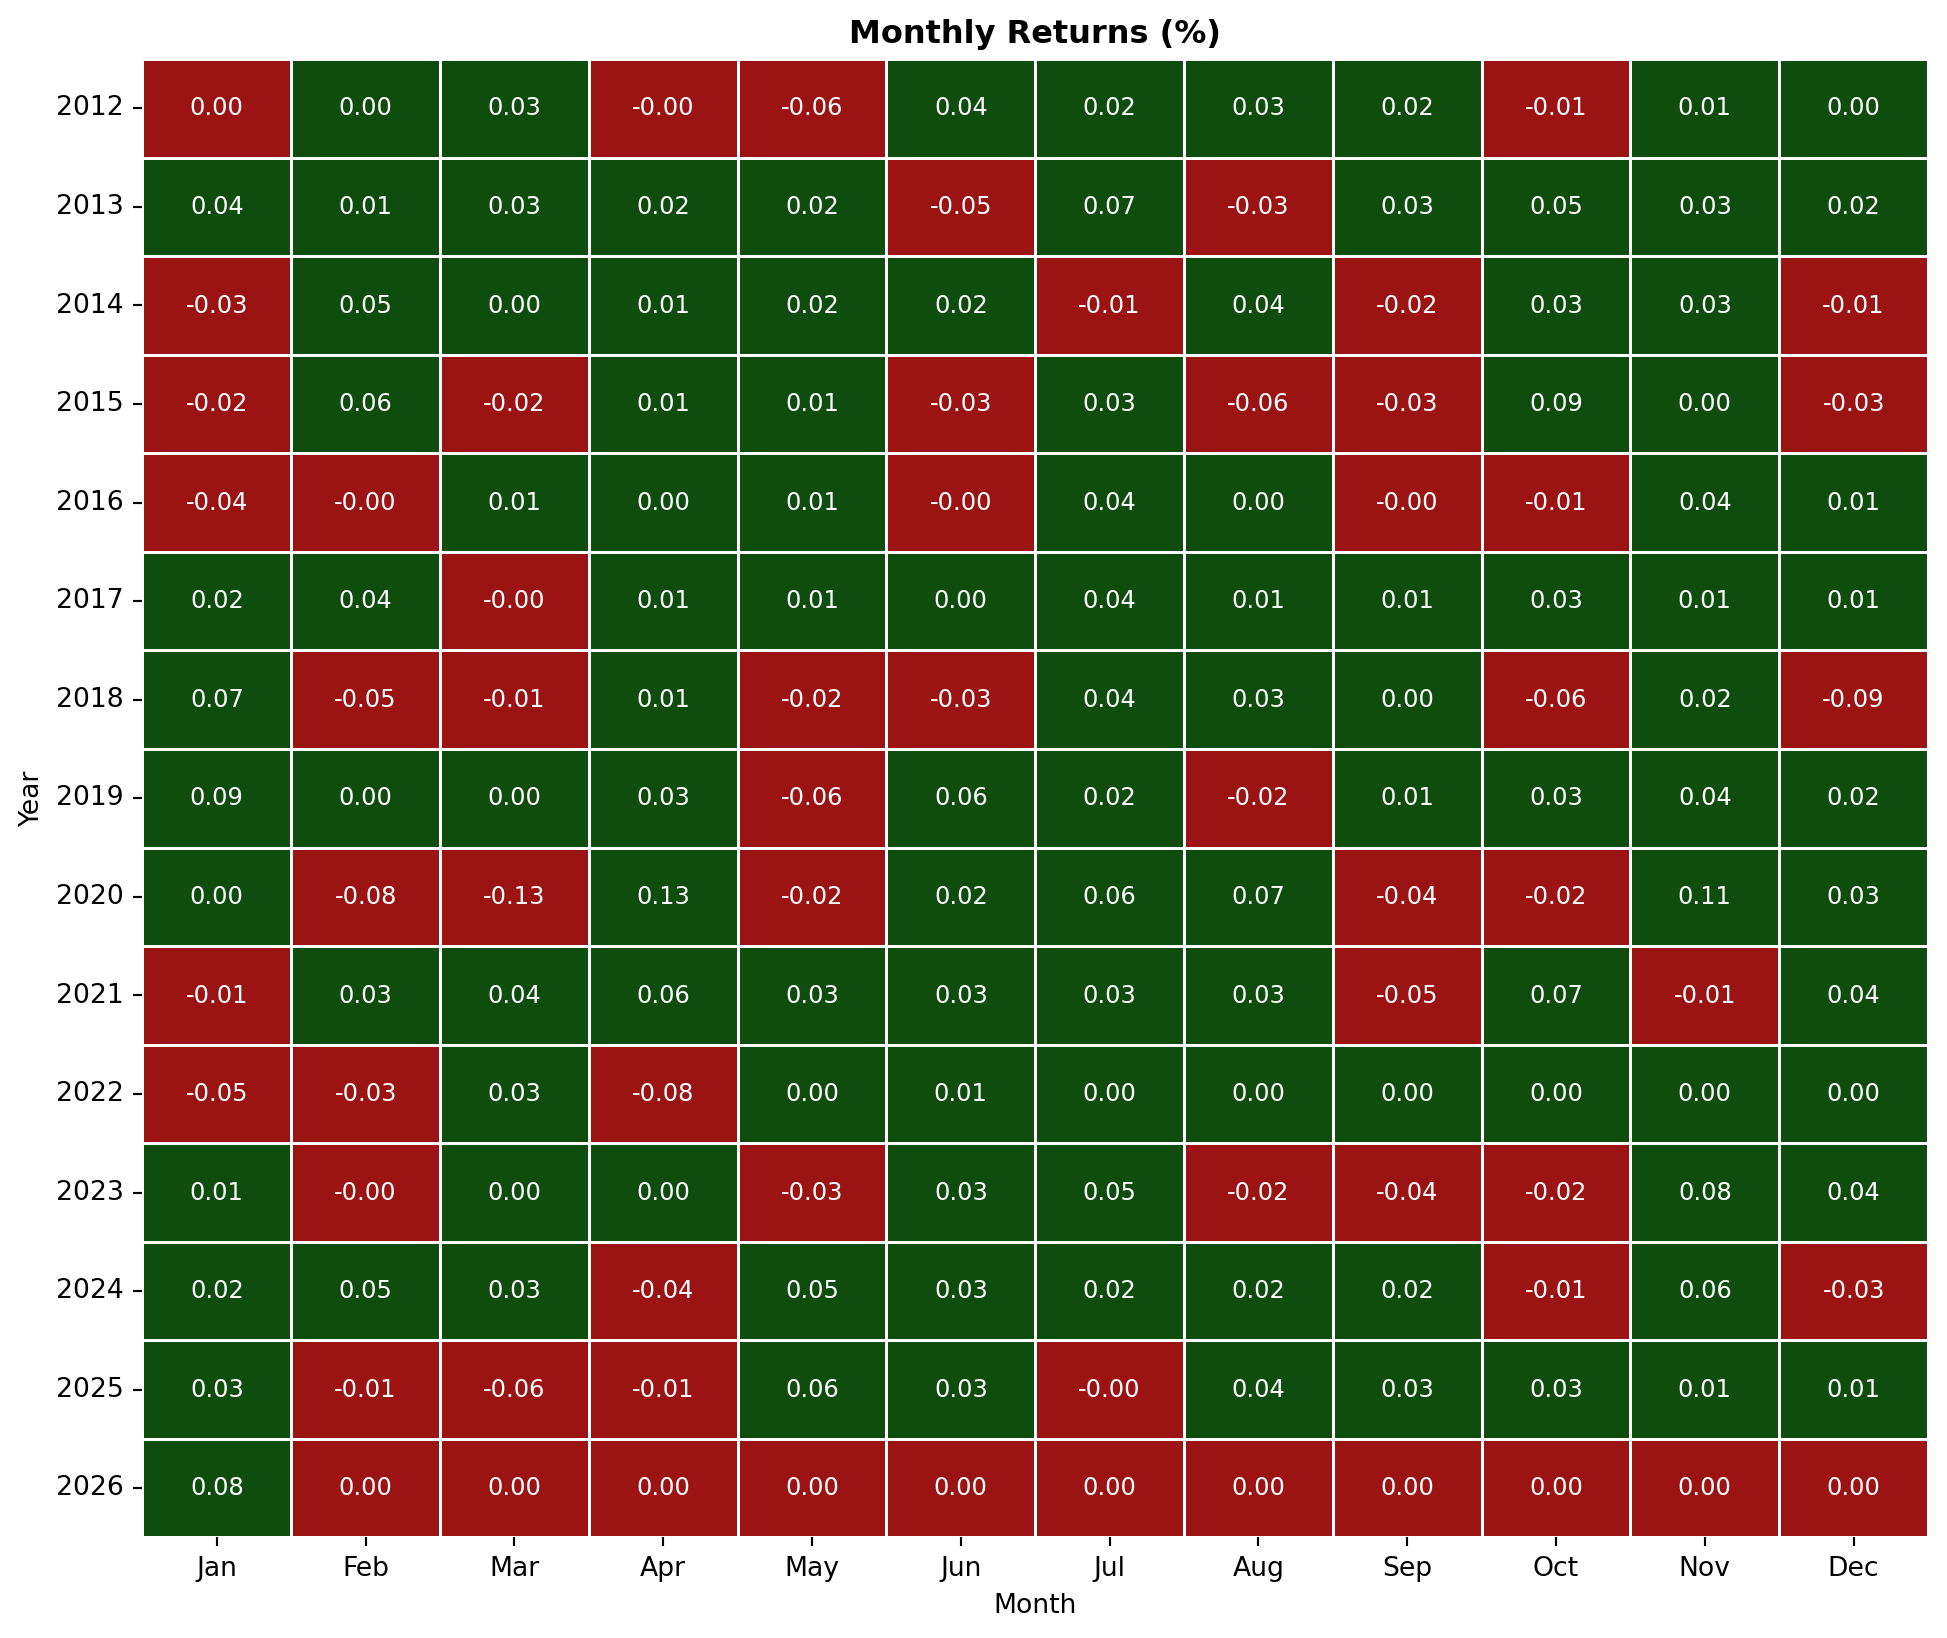

In [14]:
main.monthly_pos_neg_returns(os_result.returns)

#### Trades Analysis

In [15]:
os_result.trades

,symbol,open_date,close_date,bars_held,open_price,close_price,position_size,profit_loss,change_pct,trade_commission,cumulative_return,current_open_positions,why_exit
0,BIL,2012-02-01,2012-03-01,1,74.49,74.49,1342.46,0.00,0.00,0.00,100000.00,1,None
1,SPY,2012-03-01,2013-01-01,10,107.25,115.85,932.44,8024.01,8.02,0.00,108024.02,1,None
2,VEU,2013-01-01,2013-02-01,1,31.30,31.84,3451.15,1863.30,1.72,0.00,109887.32,1,None
3,SPY,2013-02-01,2013-06-01,4,120.27,131.38,913.64,10145.25,9.23,0.00,120032.57,1,None
4,VEU,2013-06-01,2013-07-01,1,31.49,30.63,3811.91,-3284.36,-2.74,0.00,116748.21,1,None
5,SPY,2013-07-01,2015-11-01,28,130.00,175.51,898.05,40873.40,35.01,0.00,157621.61,1,None
6,BIL,2015-11-01,2015-12-01,1,74.26,74.28,2122.49,34.46,0.02,0.00,157656.07,1,None
7,SPY,2015-12-01,2016-03-01,3,176.46,165.28,893.45,-9988.59,-6.34,0.00,147667.49,1,None
8,BIL,2016-03-01,2016-05-01,2,74.26,74.31,1988.45,96.99,0.07,0.00,147764.48,1,None
9,SPY,2016-05-01,2016-06-01,1,176.28,178.15,838.25,1571.02,1.06,0.00,149335.50,1,None


In [16]:
os_result.open_positions

,symbol,open_date,last_date,bars_holding,open_price,last_price,position_size,profit_loss,change_pct,current_value
0,VEU,2025-11-01,2026-01-01,4,71.63,77.73,6262.21,38176.80,8.51,486761.68


At a first glance, it appears to exist several 1 month trades suggesting potential signal whipsaws.
All 3 tickers got traded in the sample period.

In [17]:
tools.metrics_trades(os_result.trades, full_metrics=True)

,Trades Analysis
Nr trades,29.00
Win Rate %,79.31
Profit Factor,11.37
Avg. Win %,7.51
Avg. Loss %,-2.70
Reward/Risk,2.78
Expectancy %,5.40
Avg. Bars Held,5.00
Commissions,0.00
Max Bars Held,28.00


For the sample period, TAA Dual Momentum strategy made 29 trades, averaging ~2 trades per year. No transaction costs were considered in this backtest. Longest trade lasted 28 months (that's 2 years and 4 months), on average each trade lasted about 5 months.

Incredibly 75% of the trades were winners with a 40% profit return for the best trade and -6.3% for the worst trade. With a 3.3 Reward/Risk, on average winning trades are 3.3x bigger than losing trades.

As per the backtest expectancy, on each new trade it is expected to harvest ~5.4% profit.

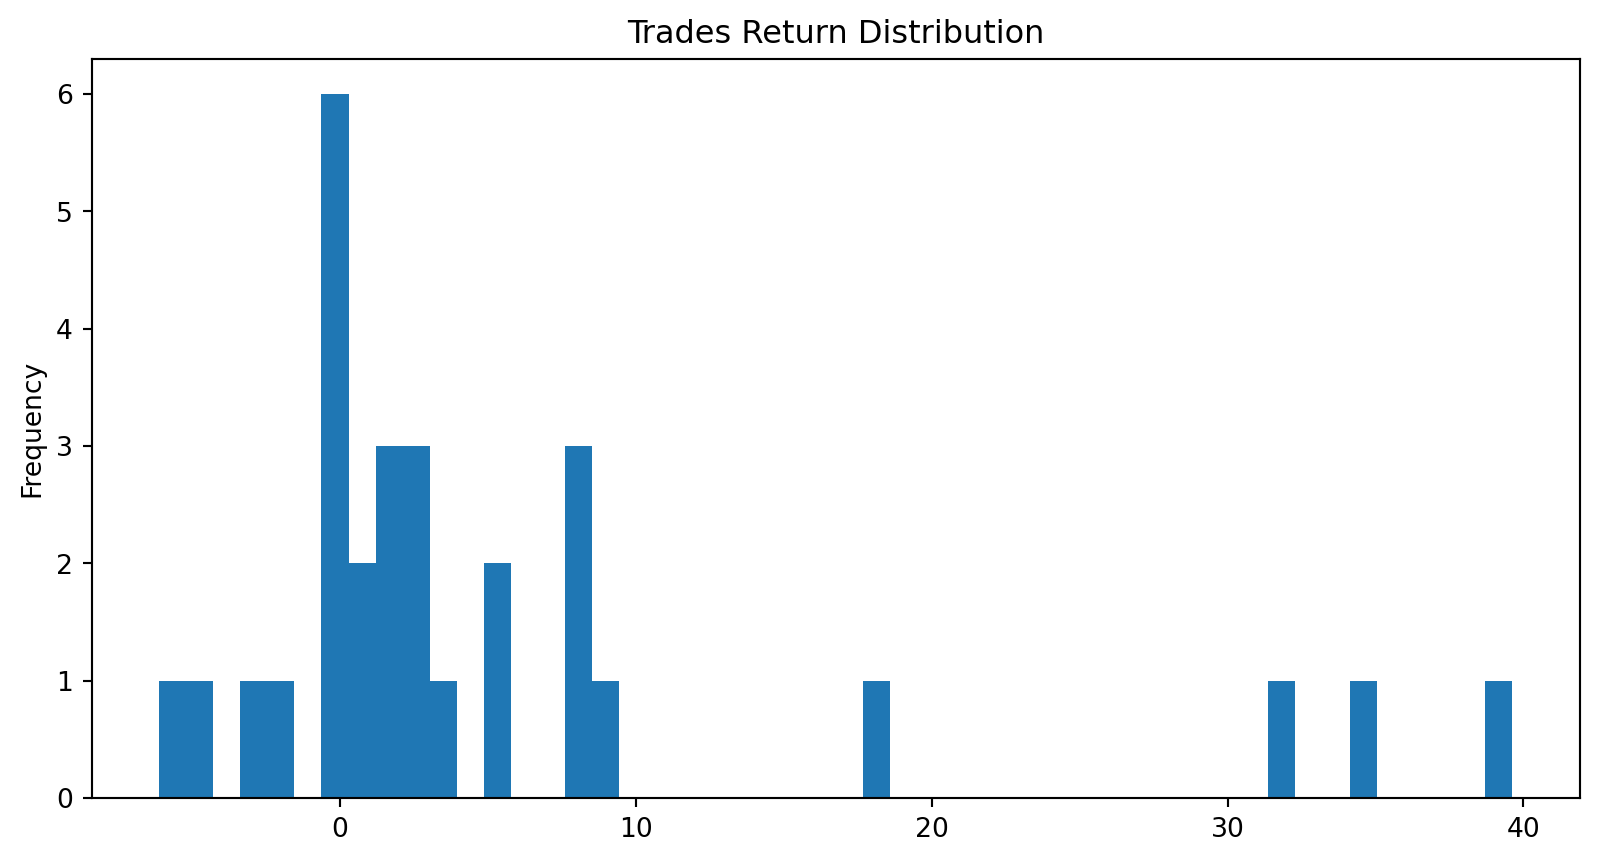

In [18]:
clipped_returns = main.cap_series(os_result.trades['change_pct'], percentile=0.005)
ax1 = clipped_returns.plot.hist(bins=50, title="Trades Return Distribution", figsize=(10, 5))

Strategy is working as intended, cutting losses short and letting profits run.

Avg. Bars Held: 5


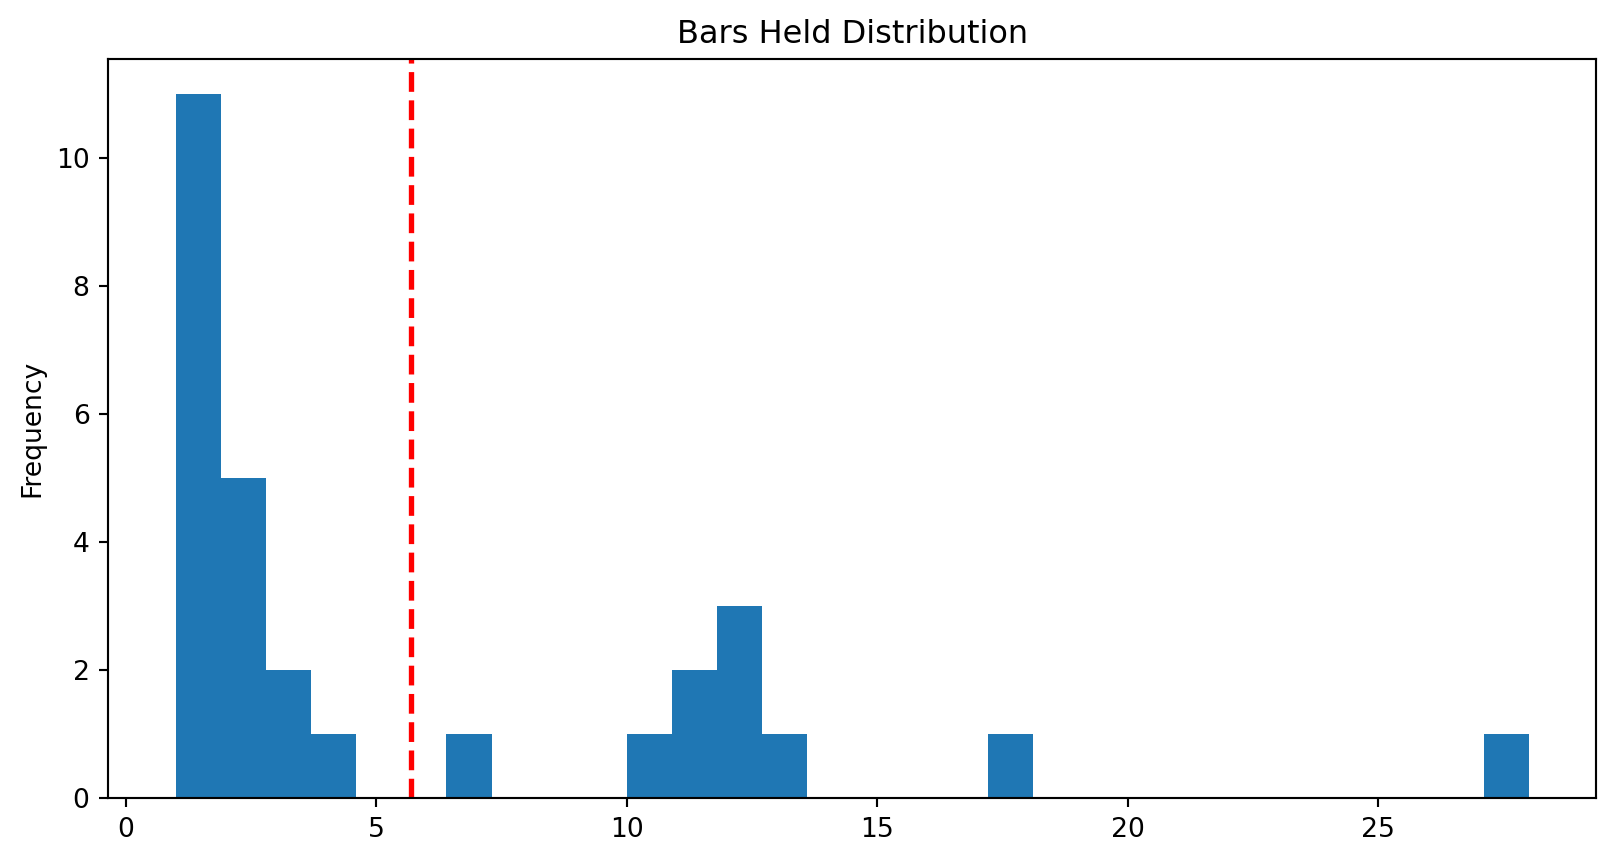

In [19]:
ax2 = os_result.trades['bars_held'].plot.hist(bins=30, title="Bars Held Distribution", figsize=(10, 5))
ax2.axvline(os_result.trades['bars_held'].mean(), color='red', linestyle='dashed', linewidth=2)
print("Avg. Bars Held:", int(os_result.trades['bars_held'].mean()))

Average trade lasted 5 months, about 11 trades only lasted 1 month eroding profits potential due to transactional costs.

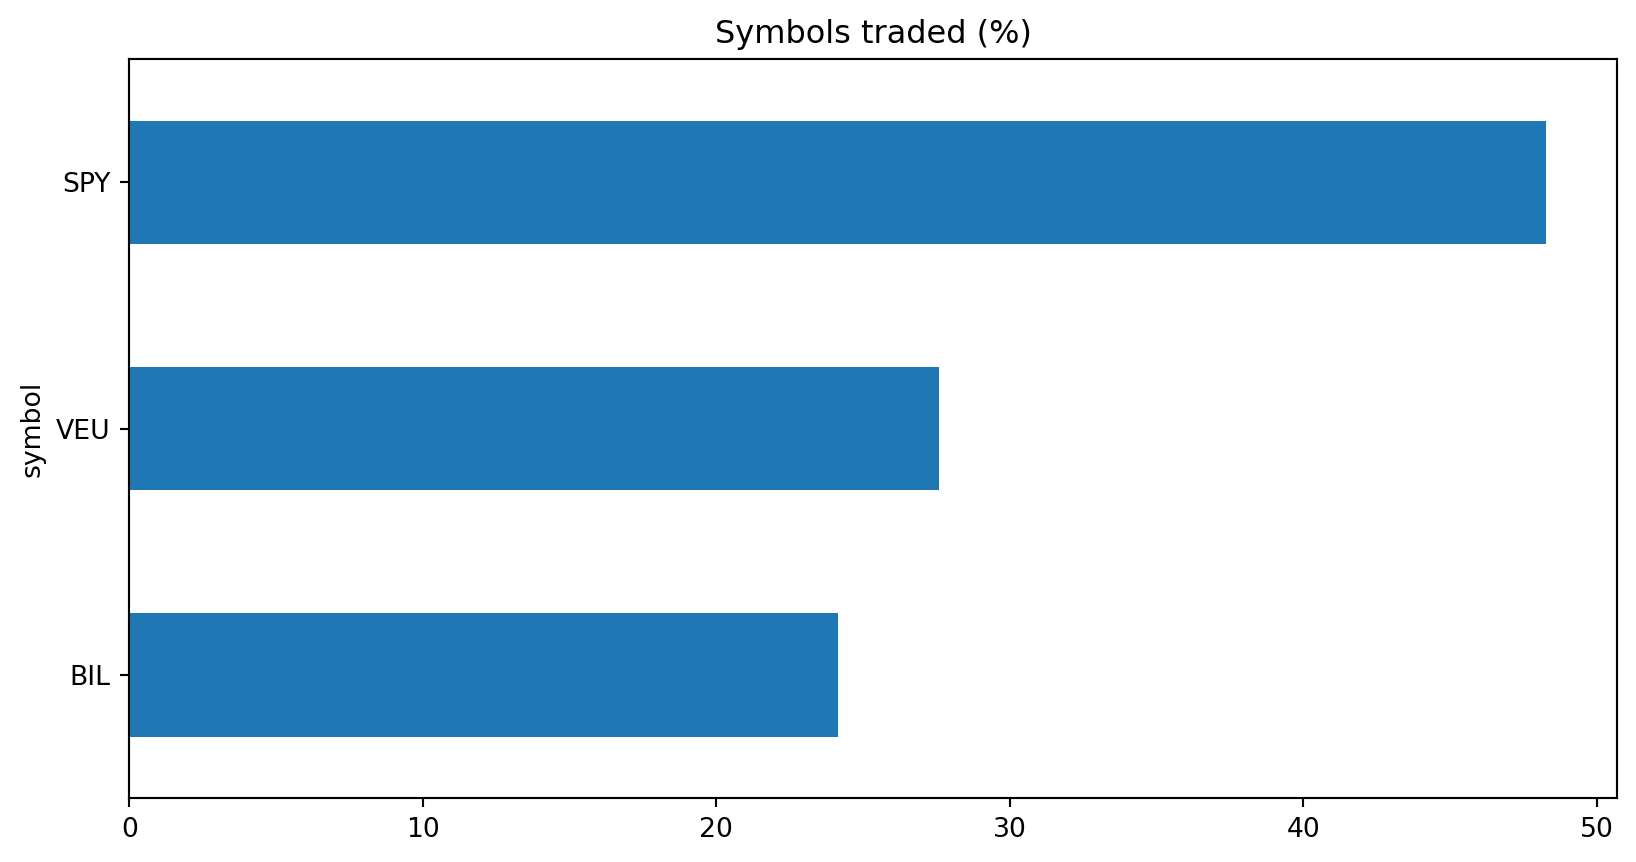

In [20]:
symbols_traded = (os_result.trades.groupby(['symbol']).size()/len(os_result.trades)*100).sort_values()
ax3 = symbols_traded.plot.barh(title='Symbols traded (%)', figsize=(10,5))

The T Bills ETF (BIL), was the least traded asset as TAA Dual Momentum strategy didn't need to risk off often, as shown by the almost 50% of the trades being US Equities (SPY) and 25%+ the All-World ex-US (VEU).

TAA strategy was invested in risky assets 88.5% of the time.


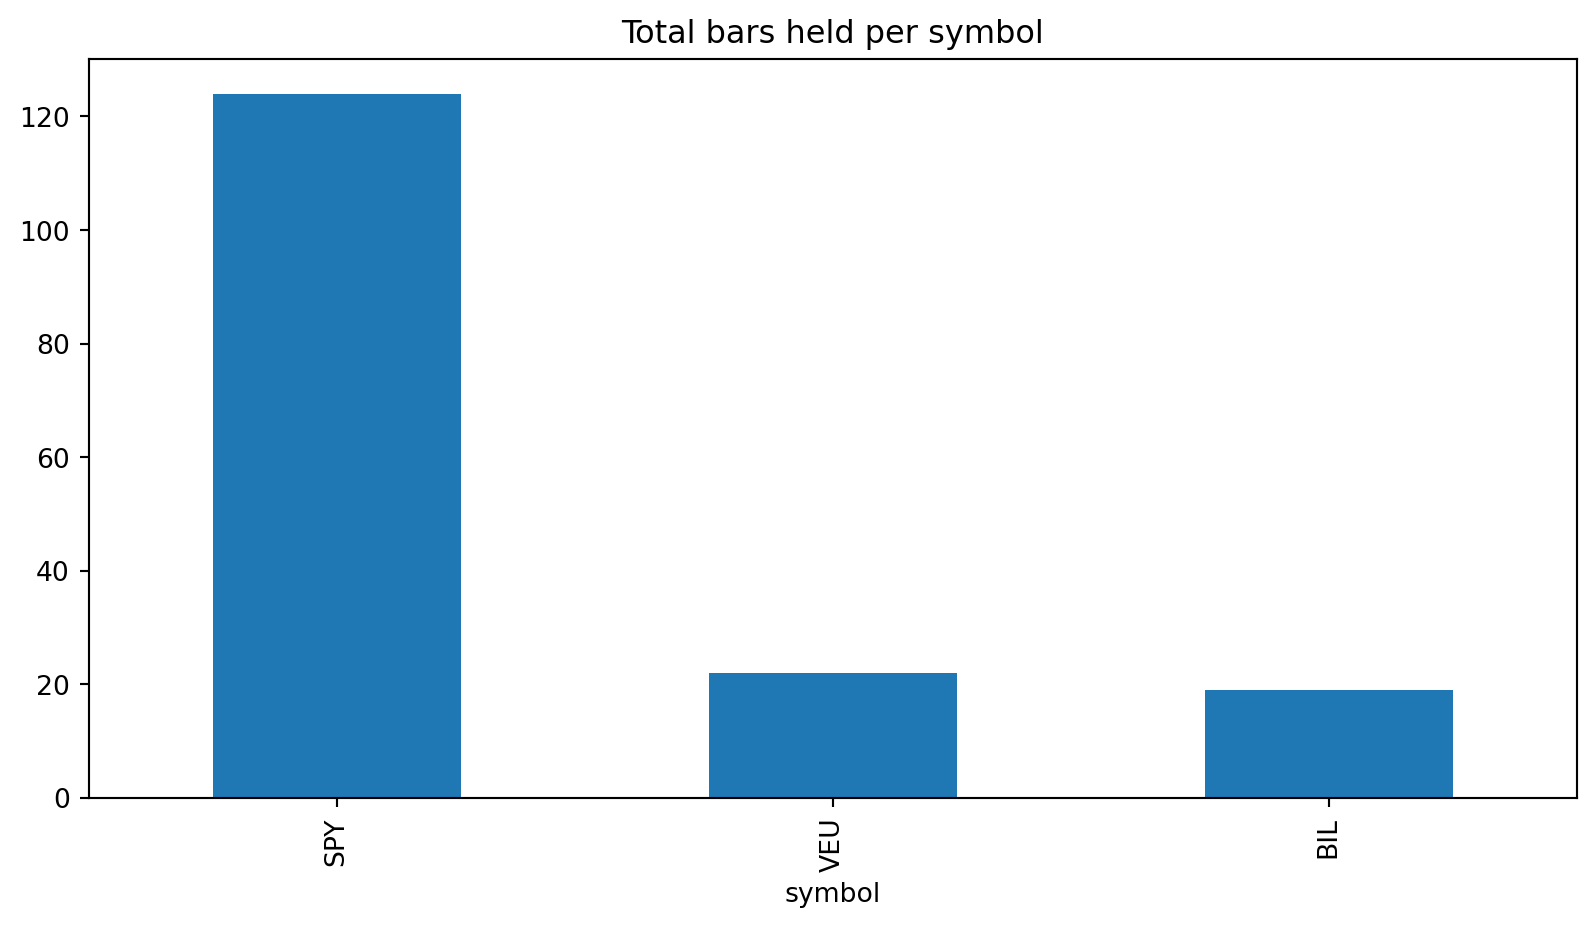

In [21]:
bars_per_symbol = os_result.trades.groupby("symbol")["bars_held"].sum().sort_values(ascending=False)
ax4 = bars_per_symbol.plot.bar(title='Total bars held per symbol', figsize=(10,5))
print(f"TAA strategy was invested in risky assets {(1 - bars_per_symbol.BIL / bars_per_symbol.sum()):.1%} of the time.")

Since the strategy only moved into risk-off assets occasionally, it didn’t really have much opportunity to outperform Buy & Hold. As mentioned earlier, the sample period coincided with a strong secular bull market in US equities, which helps explain the relative underperformance of the TAA strategy.

In [22]:
import plotly.express as px

ax5 = px.scatter(os_result.trades, 
                 x='bars_held',
                 y='change_pct',
                 width=900,
                 height=500,
                 trendline="ols",
                 trendline_color_override="black",
                 title='Trade duration VS Trade Profit',
                 template='seaborn'
                 )

ax5.show()

The chart suggests a positive relationship between trade duration and profitability, with longer-held trades generally producing higher returns.

#### Statistical Analysis

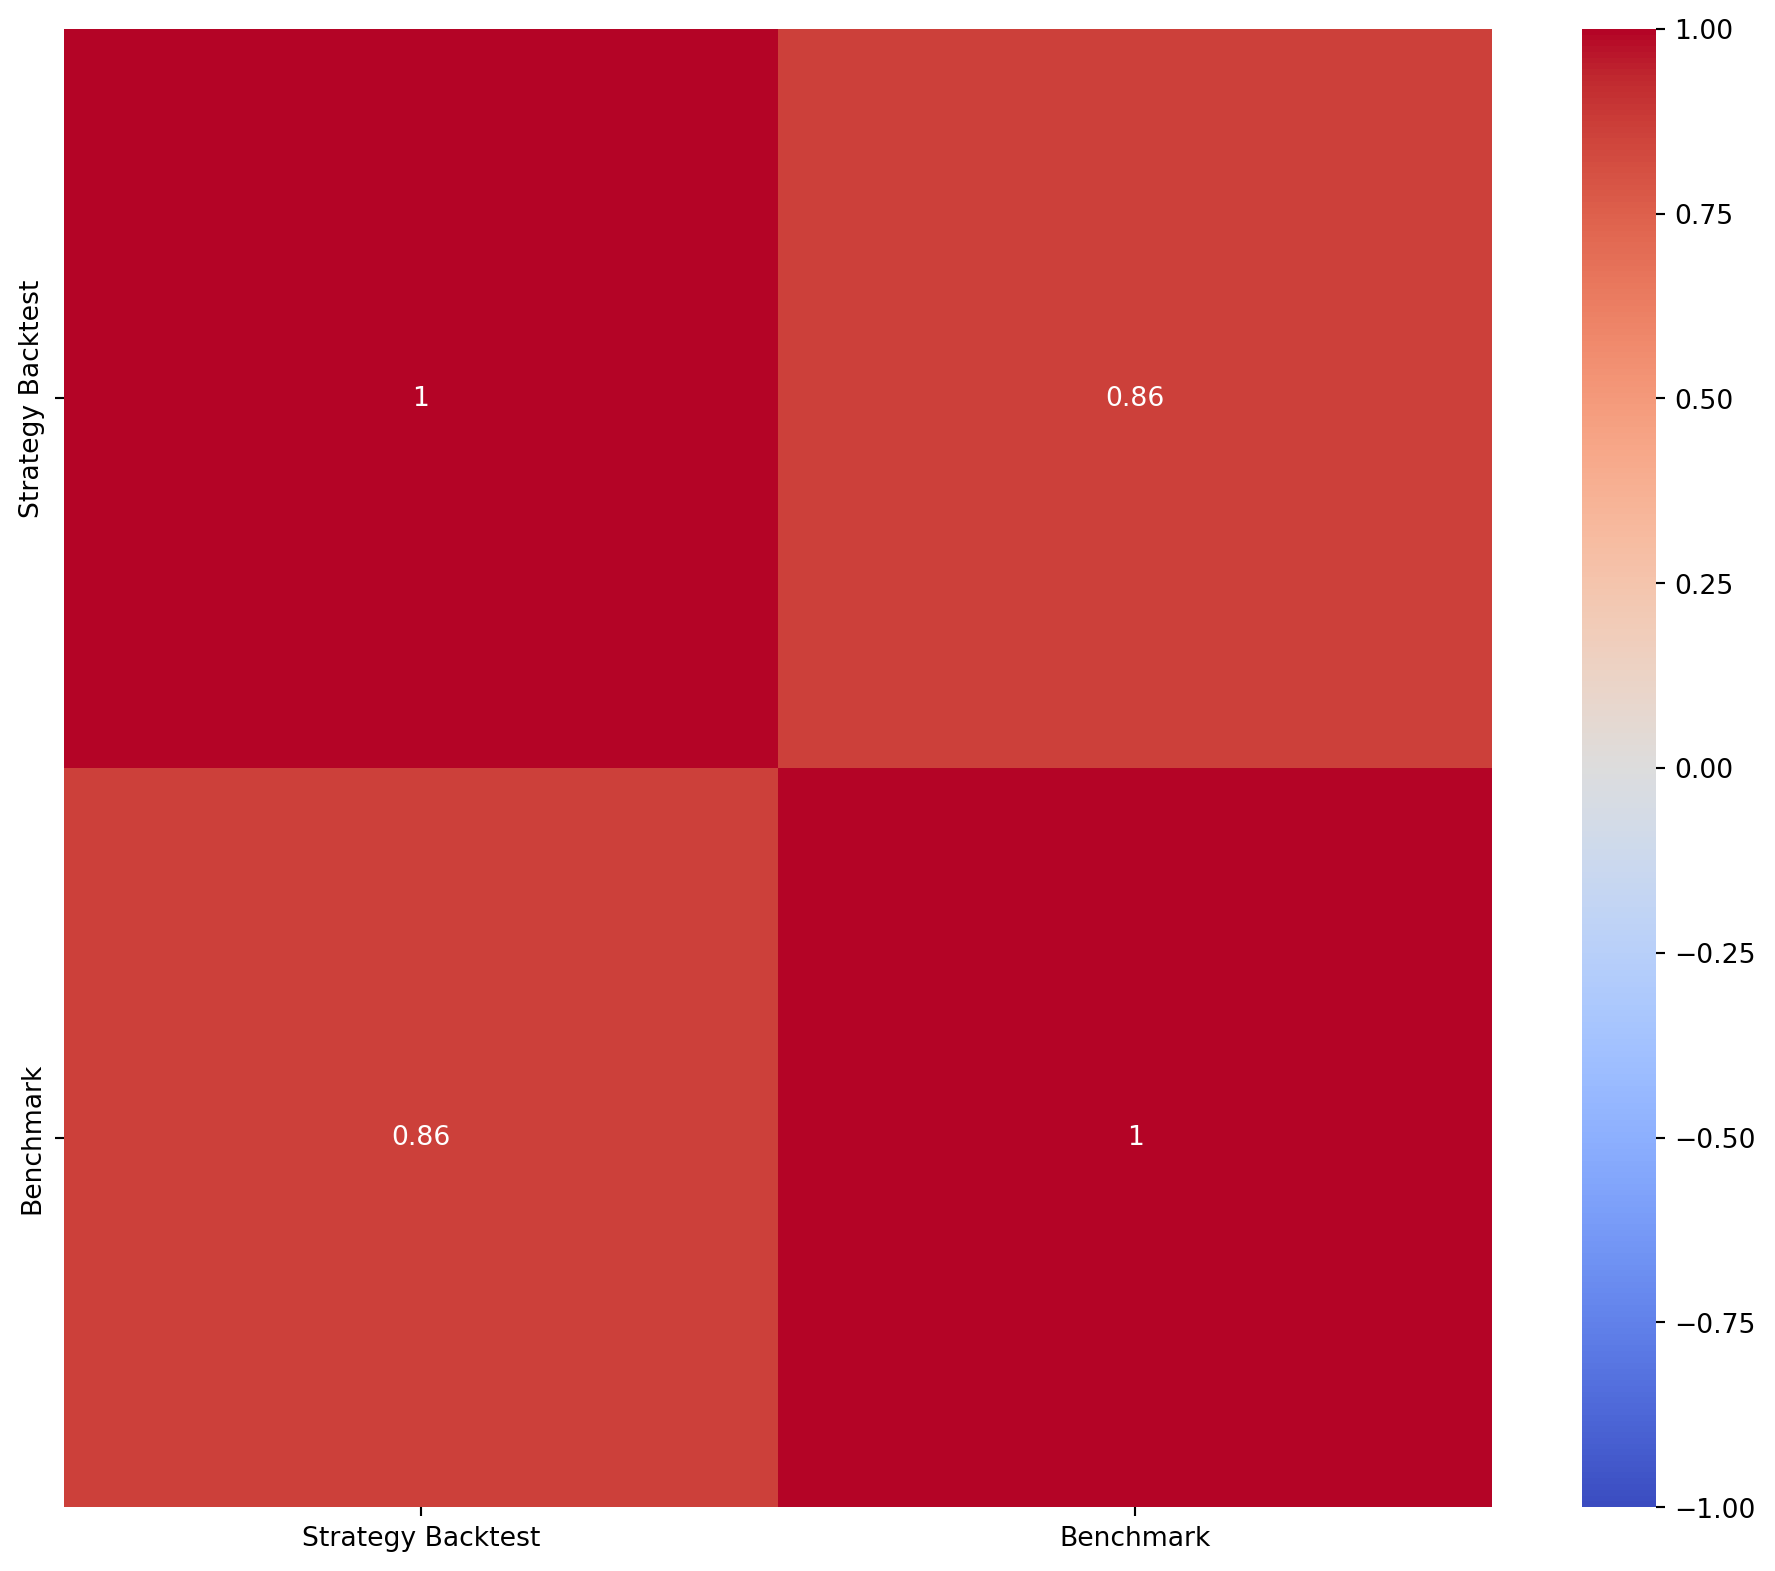

In [23]:
main.correlation_map(pd.concat([os_result.returns, os_result.benchmark], axis=1))

The tested Dual Momentum TAA Strategy has a 0.86 correlation with US Equities Buy & Hold, which is not surprising after having previously observed that ~88.5% of the time, strategy was invested in risky assets, most of it was US Equities themselves. For the smaple period strategy has behaved much more like an equity exposure with timing adjustments, rather than an independent return source.

##### Is it significantly different from 0?

In [24]:
main.compute_t_test(os_result.returns)

P-value: 0.0005499811126983559 Reject the null hypothesis (H₀). The strategy average return is significantly different from zero.


##### Does it pass Monte Carlo Permutation?

This will shuffle the given equity curve returns in random order, all output equity curves start and end at the same place, only the path will vary, to obtain Confidence Intervals for Max Draw Down Figures.

In [25]:
mcpyt = main.monte_carlo_permutation_yt(os_result.returns, nr_simulations=1000)

In [26]:
mcpyt.tail(3)

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
2025-11-01,4.53,4.59,4.88,5.03,4.62,4.53,4.67,4.64,5.01,4.69,...,5.34,4.37,5.23,4.98,4.63,4.56,4.71,4.47,4.89,4.96
2025-12-01,4.70,4.74,4.74,4.81,4.75,4.86,4.75,4.78,5.02,4.78,...,5.12,4.73,5.06,4.86,4.80,4.75,4.78,4.65,4.90,4.95
2026-01-01,4.87,4.87,4.87,4.87,4.87,4.87,4.87,4.87,4.87,4.87,...,4.87,4.87,4.87,4.87,4.87,4.87,4.87,4.87,4.87,4.87


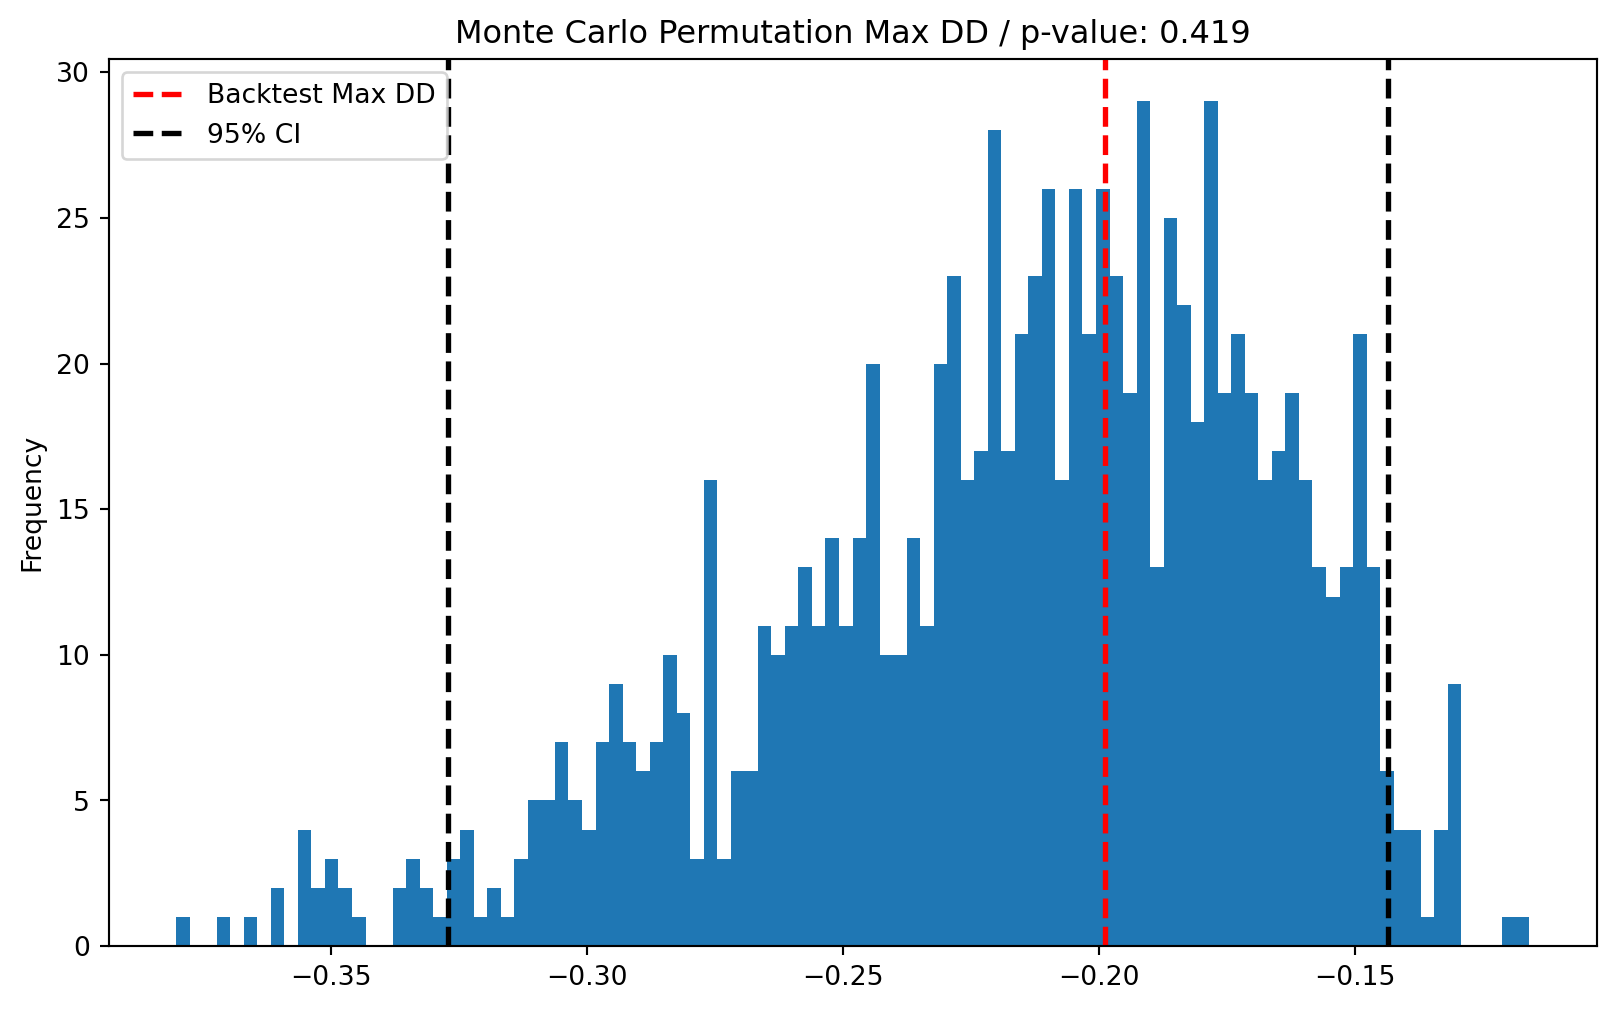

In [27]:
main.mcpyt_analysis(mcpyt, os_result.returns, ci=95)

The Monte Carlo analysis shows that the observed backtest drawdown (~-20%) falls near the center of the simulated distribution, indicating it is a typical outcome for the strategy. The p-value of 0.433 suggests that roughly 43% of simulations produced drawdowns equal to or worse than the observed one, meaning the backtest does not appear unusually lucky or unlucky in terms of return sequencing.

The 95% range of simulated outcomes lies approximately between -13% and -34%, implying that deeper drawdowns than the one observed remain plausible under different market paths. 

Overall, the results suggest that the backtest is not artificially optimistic due to a favorable ordering of returns and investors should expect deeper drawdowns than those observed in the backtest.

## Final Thoughts



This study evaluated a Dual Momentum TAA strategy over an out-of-sample period from 2012 to 2026, the analysis shows that while the Dual Momentum TAA strategy modestly reduced volatility and drawdowns, it underperformed Buy & Hold US equities in both absolute and risk-adjusted terms over the sample period. 

The strategy remained largely exposed to equity risk, resulting in a high correlation with the benchmark. In a prolonged secular bull market, this structure limited the opportunity for defensive allocations to add meaningful value.